## What is a Scatter Matrix?

A scatter matrix is a grid of plots where:

- Each off-diagonal cell → scatter plot between two variables

- Each diagonal cell → distribution (hist/KDE) of a single variable

- Used to:

    - detect correlation

    - detect clusters

    - spot non-linearity

    - find outliers

### PART 1 — Basic Scatter Matrix (Pandas)
Simplest form (quick EDA)

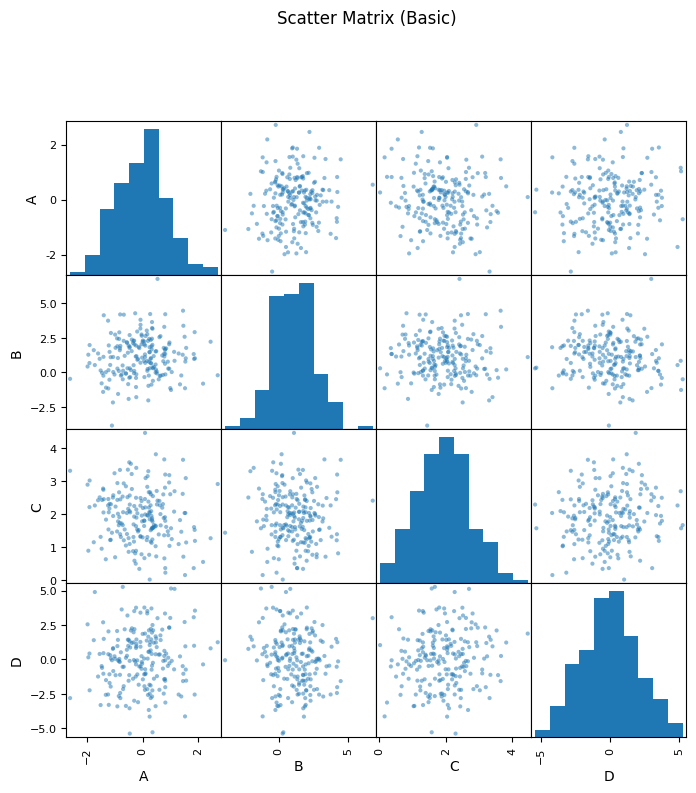

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.DataFrame({
    "A": np.random.normal(0, 1, 200),
    "B": np.random.normal(1, 1.5, 200),
    "C": np.random.normal(2, 0.8, 200),
    "D": np.random.normal(0, 2, 200)
})

pd.plotting.scatter_matrix(
    df,
    figsize=(8, 8),
    diagonal="hist"
)

plt.suptitle("Scatter Matrix (Basic)", y=1.02)
plt.show()


### PART 2 — Scatter Matrix with KDE on Diagonal

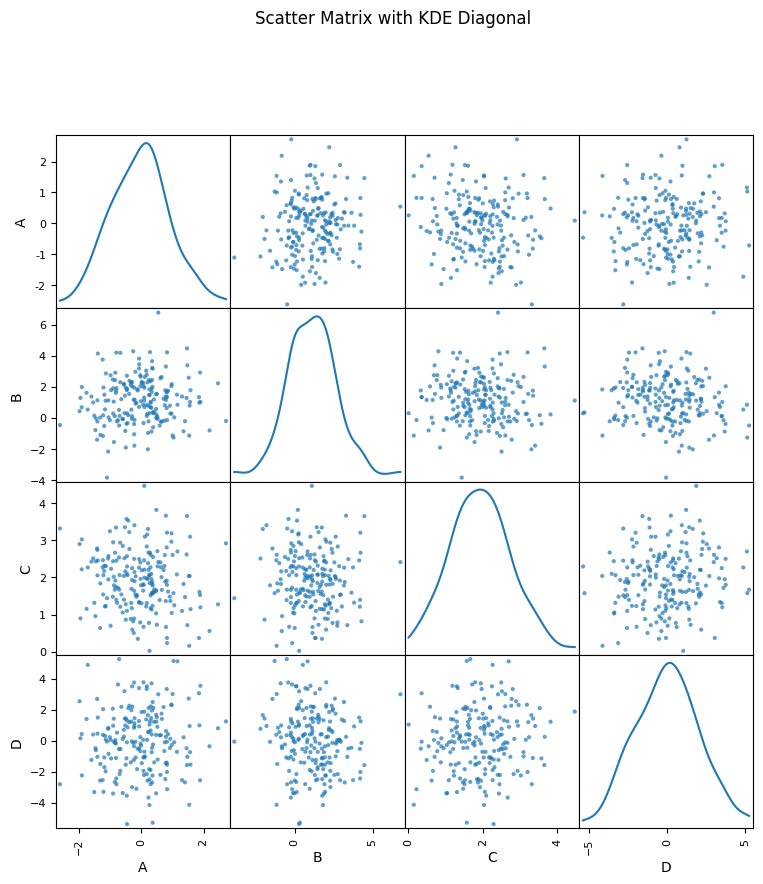

In [2]:
pd.plotting.scatter_matrix(
    df,
    figsize=(9, 9),
    diagonal="kde",
    alpha=0.7
)

plt.suptitle("Scatter Matrix with KDE Diagonal", y=1.02)
plt.show()


### PART 3 — Colored Scatter Matrix (Class-Based)

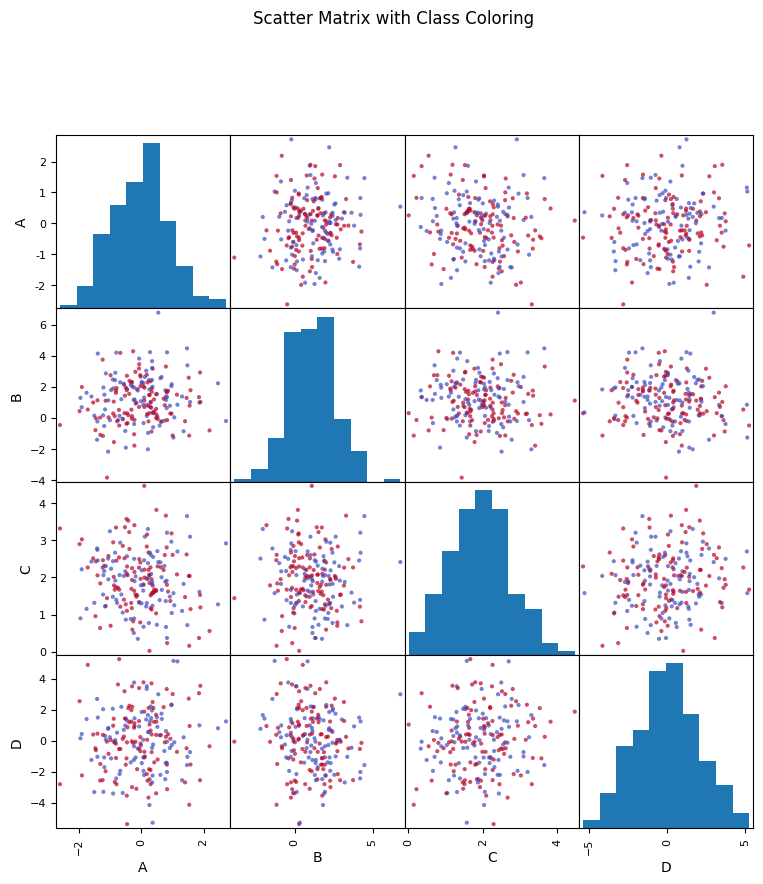

In [3]:
labels = np.random.choice(["Class A", "Class B"], size=len(df))

pd.plotting.scatter_matrix(
    df,
    figsize=(9, 9),
    c=(labels == "Class A"),
    cmap="coolwarm",
    alpha=0.7,
    diagonal="hist"
)

plt.suptitle("Scatter Matrix with Class Coloring", y=1.02)
plt.show()


### PART 4 — Seaborn PairPlot (Most Common & Powerful)

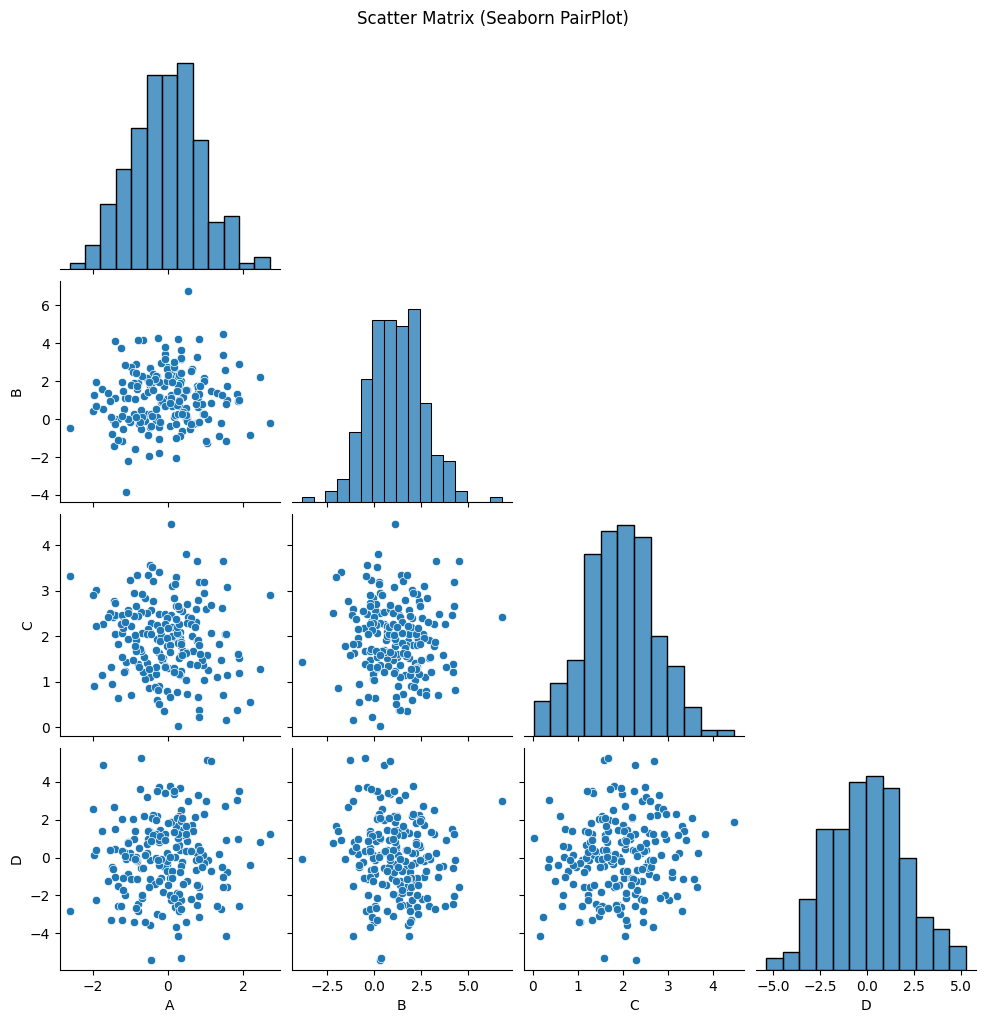

In [4]:
import seaborn as sns

sns.pairplot(
    df,
    diag_kind="hist",
    corner=True
)

plt.suptitle("Scatter Matrix (Seaborn PairPlot)", y=1.02)
plt.show()


### PART 5 — Scatter Matrix with KDE + Regression Lines

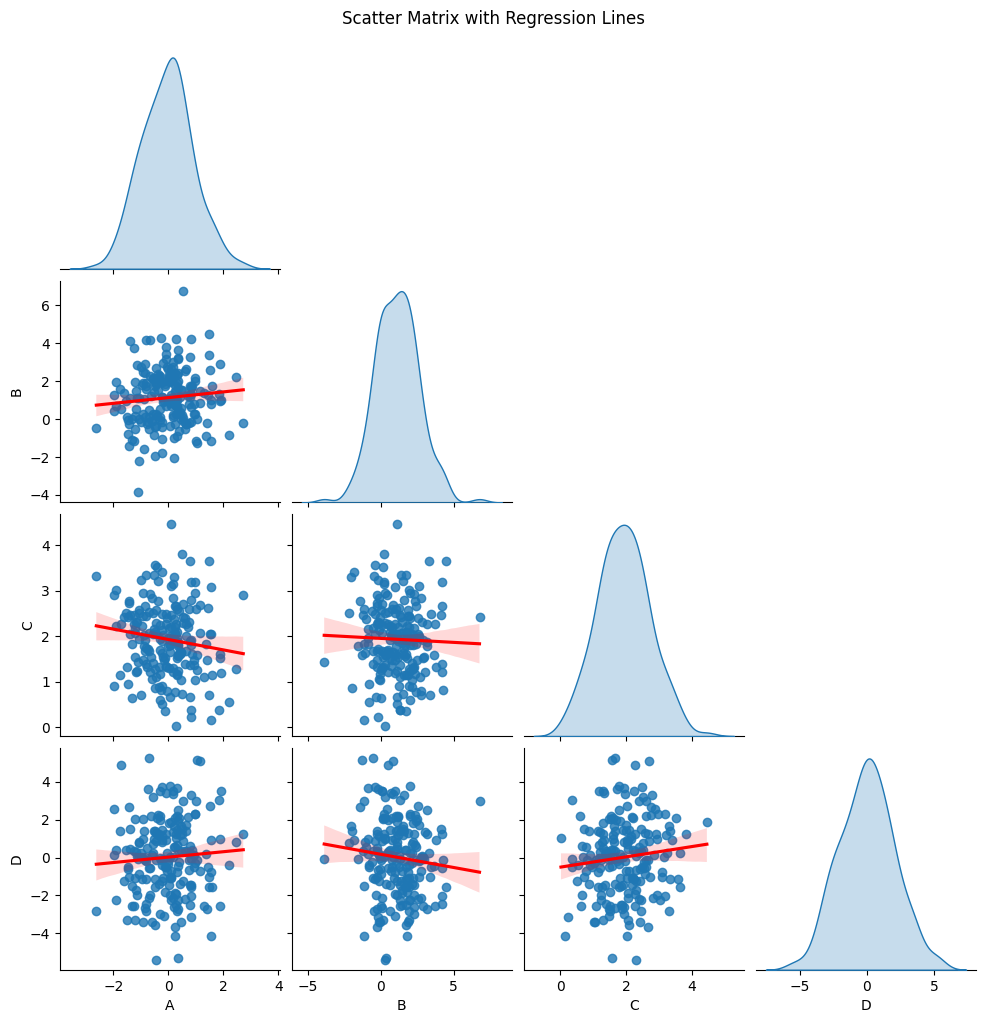

In [5]:
sns.pairplot(
    df,
    kind="reg",
    diag_kind="kde",
    corner=True,
    plot_kws={"line_kws": {"color": "red"}}
)

plt.suptitle("Scatter Matrix with Regression Lines", y=1.02)
plt.show()


### PART 6 — Scatter Matrix with Category Coloring (Hue)

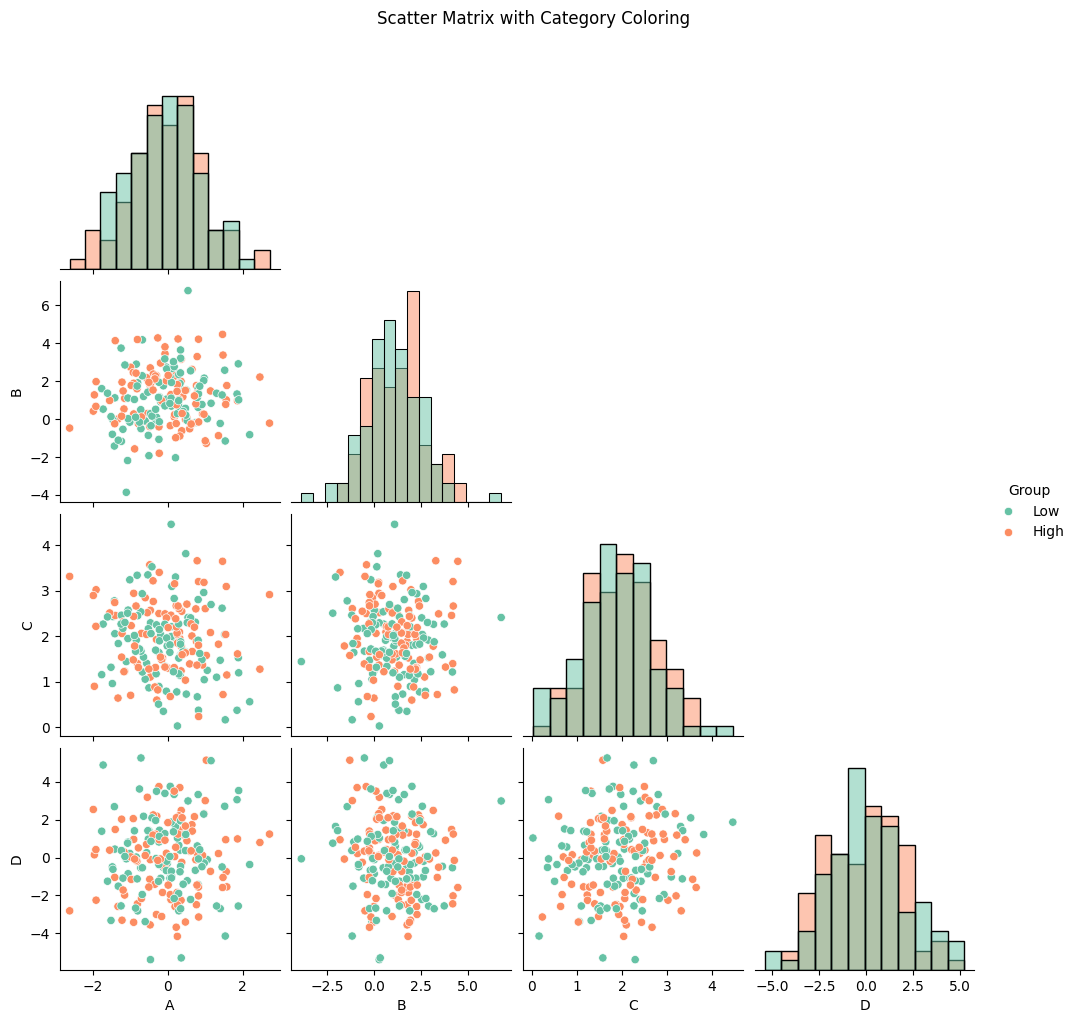

In [6]:
df["Group"] = np.random.choice(["Low", "High"], size=len(df))

sns.pairplot(
    df,
    hue="Group",
    diag_kind="hist",
    corner=True,
    palette="Set2"
)

plt.suptitle("Scatter Matrix with Category Coloring", y=1.02)
plt.show()


### PART 7 — Advanced PairGrid (Full Custom Control)

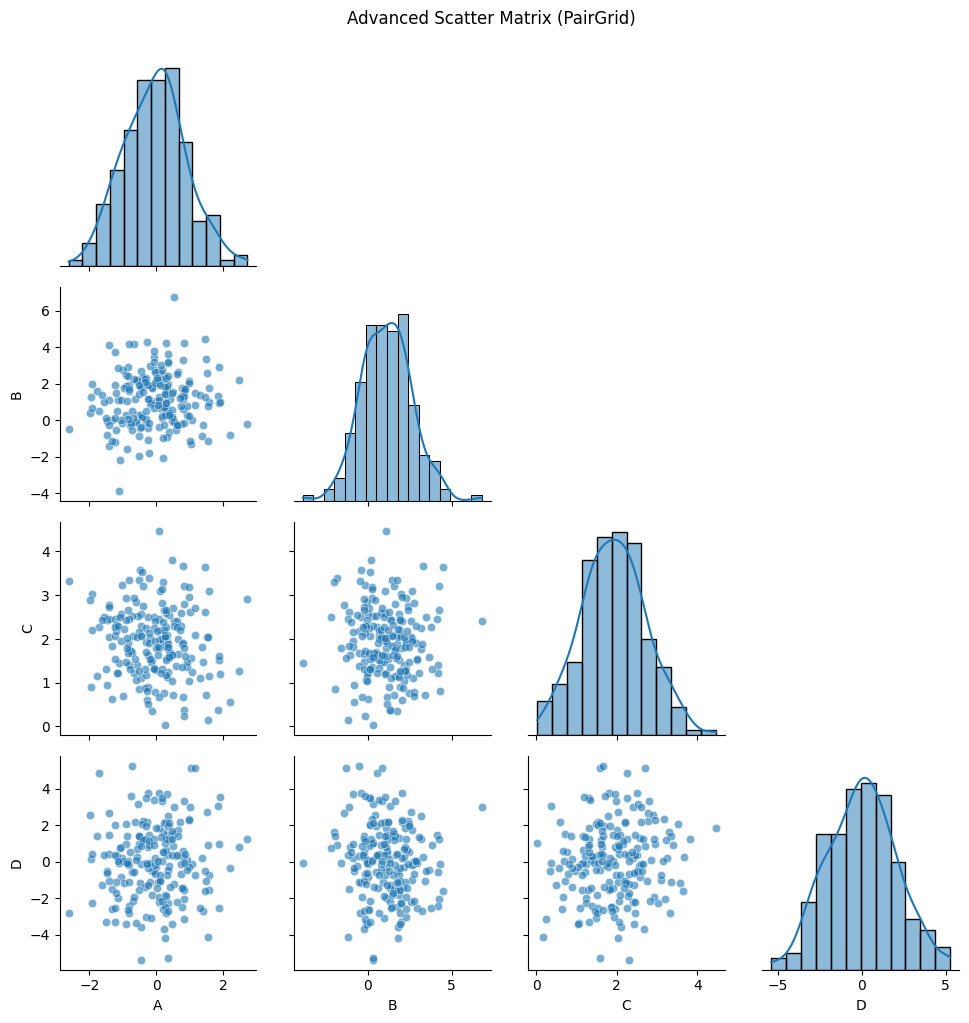

In [7]:
g = sns.PairGrid(df, corner=True)

g.map_lower(sns.scatterplot, alpha=0.6)
g.map_diag(sns.histplot, kde=True)
g.map_upper(sns.kdeplot, fill=True)

plt.suptitle("Advanced Scatter Matrix (PairGrid)", y=1.02)
plt.show()


### PART 8 — Annotated Scatter Matrix (Correlation Values)

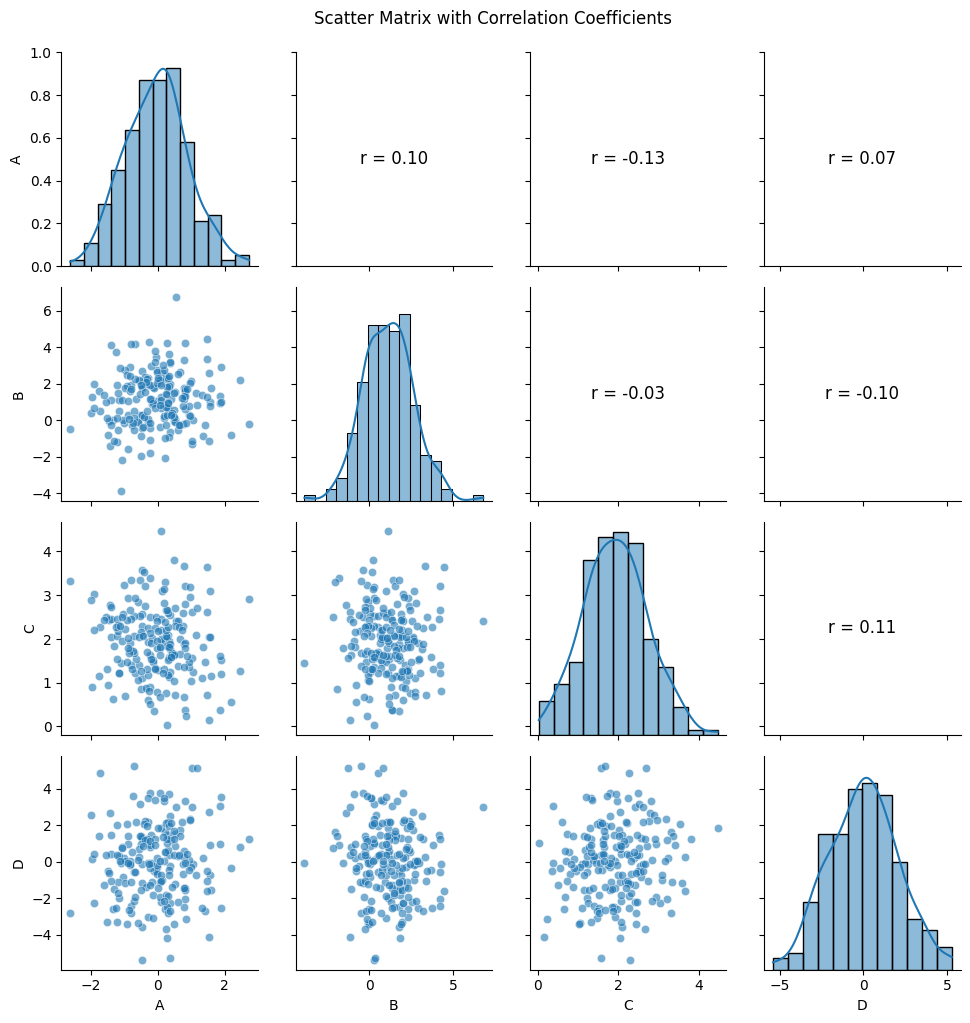

In [9]:
def corr_text(x, y, **kwargs):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}",
                xy=(0.5, 0.5),
                xycoords="axes fraction",
                ha="center",
                va="center",
                fontsize=12)

g = sns.PairGrid(df)
g.map_lower(sns.scatterplot, alpha=0.6)
g.map_diag(sns.histplot, kde=True)
g.map_upper(corr_text)

plt.suptitle("Scatter Matrix with Correlation Coefficients", y=1.02)
plt.show()


### PART 9 — Large Dataset Optimization (Sampling)

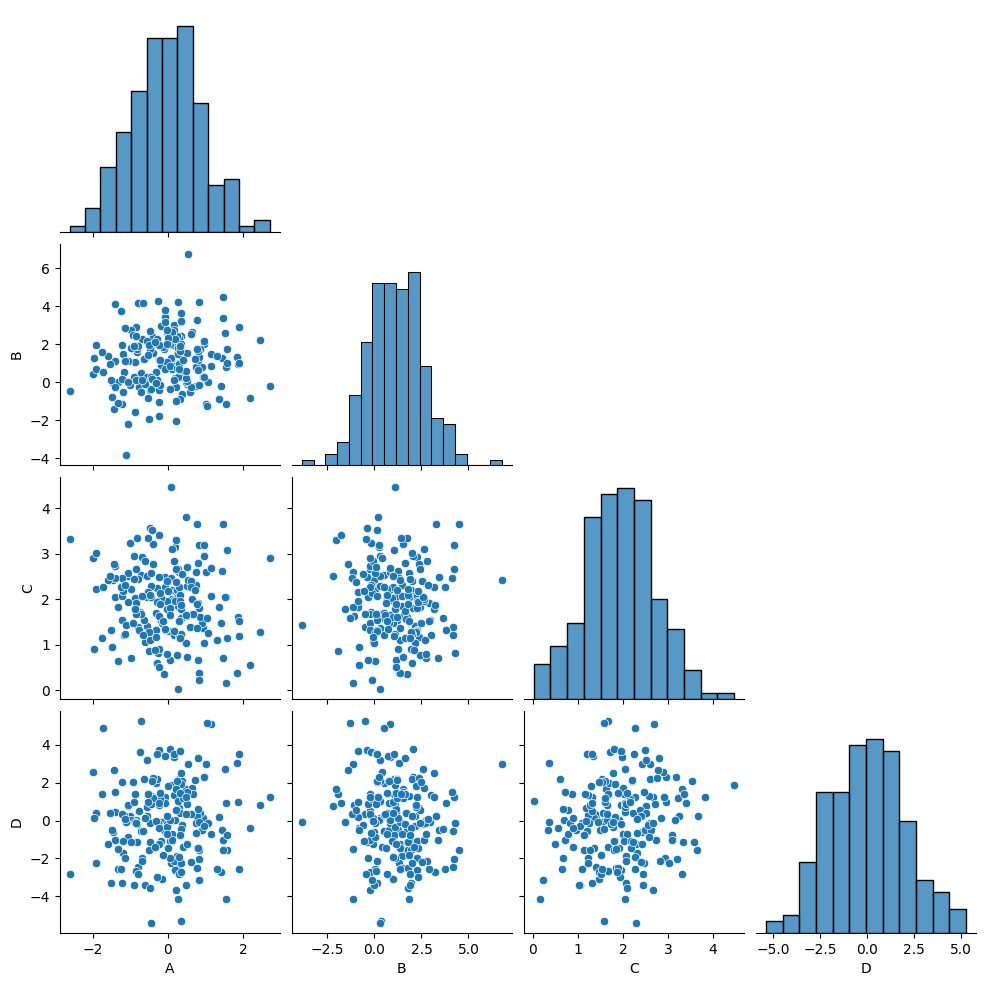

In [14]:
sampled_df = df.sample(
    n=min(500, len(df)),
    random_state=42
)

sns.pairplot(sampled_df, corner=True)
plt.show()


### PART 10 — Interactive Scatter Matrix (Plotly)

In [11]:
import plotly.express as px

fig = px.scatter_matrix(
    df,
    dimensions=df.columns,
    title="Interactive Scatter Matrix",
)

fig.show()


### PART 11 — Colored Interactive Scatter Matrix

In [12]:
fig = px.scatter_matrix(
    df,
    dimensions=df.columns,
    color=df.columns[0],
    title="Interactive Scatter Matrix with Color Encoding"
)

fig.show()


### PART 12 — Reusable Scatter Matrix Function

In [13]:
def scatter_matrix_plot(
    df,
    method="seaborn",
    hue=None,
    diag="hist"
):
    if method == "pandas":
        pd.plotting.scatter_matrix(
            df,
            figsize=(9, 9),
            diagonal=diag
        )
        plt.show()

    elif method == "seaborn":
        sns.pairplot(
            df,
            hue=hue,
            diag_kind=diag,
            corner=True
        )
        plt.show()

    elif method == "plotly":
        fig = px.scatter_matrix(df)
        fig.show()
